In [3]:
'''
will look at other features like multiplicative seasonality, outliers and non daily time intervals.
previous notebook for store had daily data, additive seasonality and was daily data.
''' 

'\nwill look at other features like multiplicative seasonality, outliers and non daily time intervals.\nprevious notebook for store had daily data, additive seasonality and was daily data.\n'

In [1]:
# pip install prophet

In [4]:
from prophet import Prophet

In [5]:
from prophet.diagnostics import cross_validation

In [6]:
from prophet.diagnostics import performance_metrics

In [7]:
from prophet.plot import plot_cross_validation_metric

In [8]:
from prophet.plot import add_changepoints_to_plot

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

### understanding data

In [11]:
df = pd.read_csv(r'airline_passengers.csv', index_col = 'Month', parse_dates = True)

In [12]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [20]:
'''sampling rate of the time series is not daily but monthly(once per month)'''

'sampling rate of the time series is not daily but monthly(once per month)'

In [13]:
df.columns = ['y']

In [14]:
df['ds'] = df.index

In [16]:
df.head()

,y,ds
Month,,
1949-01-01,112,1949-01-01
1949-02-01,118,1949-02-01
1949-03-01,132,1949-03-01
1949-04-01,129,1949-04-01
1949-05-01,121,1949-05-01


In [17]:
df.tail()

,y,ds
Month,,
1960-08-01,606,1960-08-01
1960-09-01,508,1960-09-01
1960-10-01,461,1960-10-01
1960-11-01,390,1960-11-01
1960-12-01,432,1960-12-01


In [26]:
''' training data ranging from jan 1949 to dec 1960''' 

' training data ranging from jan 1949 to dec 1960'

In [21]:
m = Prophet()

In [22]:
m.fit(df)

20:35:40 - cmdstanpy - INFO - Chain [1] start processing
20:35:40 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = m.make_future_dataframe(periods = 12, freq = 'MS')

In [27]:
future.head()

,ds
0,1949-01-01
1,1949-02-01
2,1949-03-01
3,1949-04-01
4,1949-05-01


In [24]:
future.tail()

,ds
151,1961-08-01
152,1961-09-01
153,1961-10-01
154,1961-11-01
155,1961-12-01


In [28]:
''' future dataframes has both train and predictions - predictions is now from Jan 1961 to Dec 1961'''

' future dataframes has both train and predictions - predictions is now from Jan 1961 to Dec 1961'

In [29]:
forecast = m.predict(future)

In [30]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,106.662426,57.020321,111.677050,106.662426,106.662426,-21.848267,-21.848267,-21.848267,-21.848267,-21.848267,-21.848267,0.0,0.0,0.0,84.814159
1,1949-02-01,108.835452,50.427529,107.659237,108.835452,108.835452,-30.607522,-30.607522,-30.607522,-30.607522,-30.607522,-30.607522,0.0,0.0,0.0,78.227931
2,1949-03-01,110.798186,82.984733,140.908746,110.798186,110.798186,-0.455949,-0.455949,-0.455949,-0.455949,-0.455949,-0.455949,0.0,0.0,0.0,110.342237
3,1949-04-01,112.971212,79.688026,135.136107,112.971212,112.971212,-5.160494,-5.160494,-5.160494,-5.160494,-5.160494,-5.160494,0.0,0.0,0.0,107.810718
4,1949-05-01,115.074141,82.206088,140.566212,115.074141,115.074141,-3.807887,-3.807887,-3.807887,-3.807887,-3.807887,-3.807887,0.0,0.0,0.0,111.266255


In [32]:
''' since dates are at monthly level, we will only see yearly seasonality'''
''' daily and weekly seasonality absent'''

' daily and weekly seasonality absent'

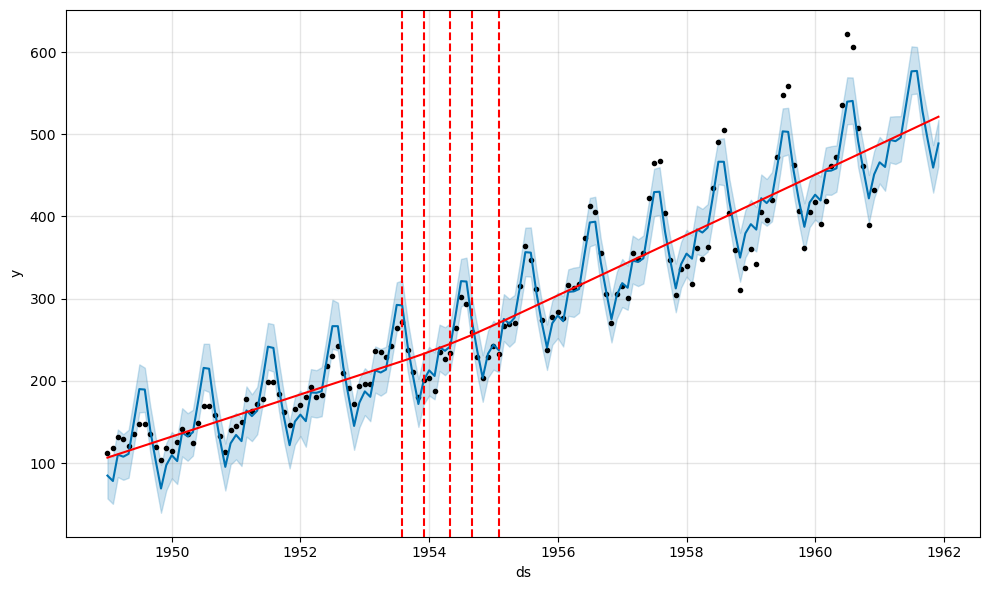

In [33]:
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [38]:
''' model clearly overestimating in the beginning and underestimating towards the end'''
''' unable to model the fact that the seasonal component is increasing in magnitude over time
    - this is happenning because by default, we have additive seasonality'''

' unable to model the fact that the seasonal component is increasing in magnitude over time\n    - this is happenning because by default, we have additive seasonality'

In [39]:
# AS YOU CAN SEE THE SEASONALITY_MODE IS ADDITIVE 
'''
m = Prophet(
                growth  = 'linear',                      # or 'logistic'
                changepoints = None,                     # or list of time stamps 
                n_changepoints = 25,                     # if no explicit timestamps provided above 
                changepoint_range = 0.8,                 # percentage of dataset where we want the potential changepoint to exist # if set to 80%, means no changepoint will
                                                         # exist in the final 20% of your dataset.
                                                         # reason for this parameter is it might overfit due to lack of data near the end
                yearly_seasonality = 'auto',             # or True/False
                weekly_seasonality ='auto',              # or True/False     
                daily_seasonality ='auto',               # or True/False     
                holidays= None,                          # or dataframe # pass in ur holidays, in a specially formatted dataframe with those dates # allows to specify surrounding days and other options
                seasonality_mode = 'additive',           # or 'multiplicative'
                seasonality_prior_scale = 10.0,          # since prophet is a bayesian model, tune the below based on the fitted values - try these values untill u get reasonable results 
                holidays_prior_scale = 10.0, 
                changepoint_prior_scale = 0.05,          # increase or decrease the sensitivity of the changepoints
                MCMC = ,                                 # not discussed here
                uncertainity intervals =,                # not discussed here 
                )
'''

"\nm = Prophet(\n                growth  = 'linear',                      # or 'logistic'\n                changepoints = None,                     # or list of time stamps \n                n_changepoints = 25,                     # if no explicit timestamps provided above \n                changepoint_range = 0.8,                 # percentage of dataset where we want the potential changepoint to exist # if set to 80%, means no changepoint will\n                                                         # exist in the final 20% of your dataset.\n                                                         # reason for this parameter is it might overfit due to lack of data near the end\n                yearly_seasonality = 'auto',             # or True/False\n                weekly_seasonality ='auto',              # or True/False     \n                daily_seasonality ='auto',               # or True/False     \n                holidays= None,                          # or dataframe # pass

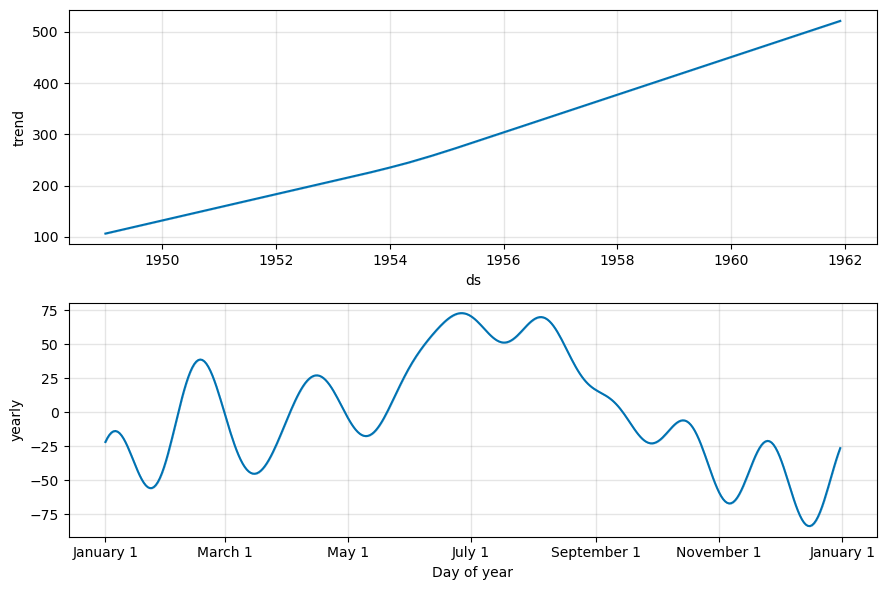

In [34]:
m.plot_components(forecast);

In [42]:
m2 = Prophet(seasonality_mode = 'multiplicative')

m2.fit(df)

future = m2.make_future_dataframe(periods = 12, freq = 'MS')

forecast = m2.predict(future)

20:52:18 - cmdstanpy - INFO - Chain [1] start processing
20:52:18 - cmdstanpy - INFO - Chain [1] done processing


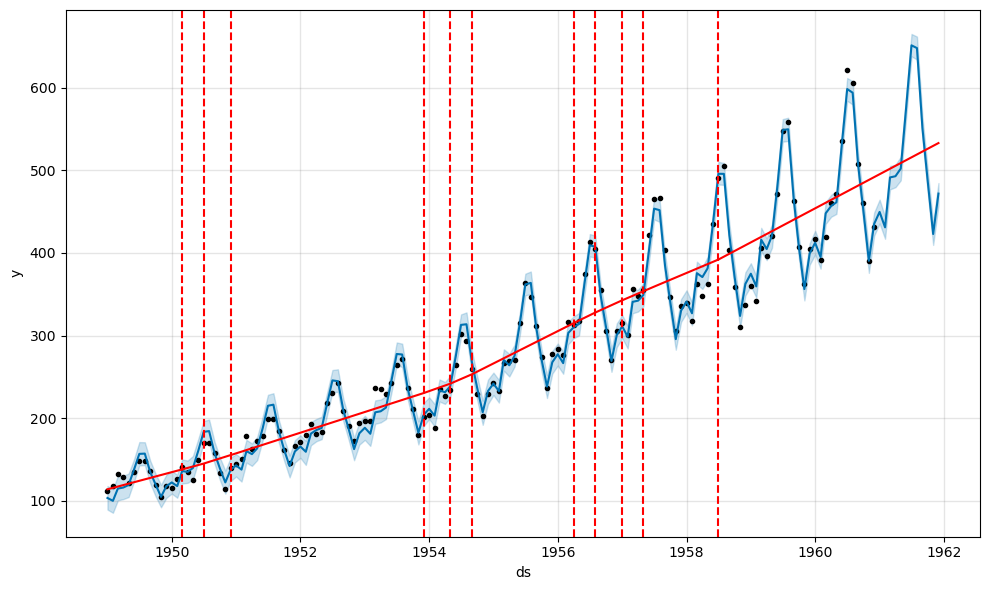

In [45]:
fig = m2.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m2, forecast)

In [49]:
''' now it is much better - model is not underpedicting and overpredicting anywhere '''
'''changepoints not much sensible since we are still using the linear model for growth
        - try experimenting with logistic growth'''

'changepoints not much sensible since we are still using the linear model for growth\n        - try experimenting with logistic growth'

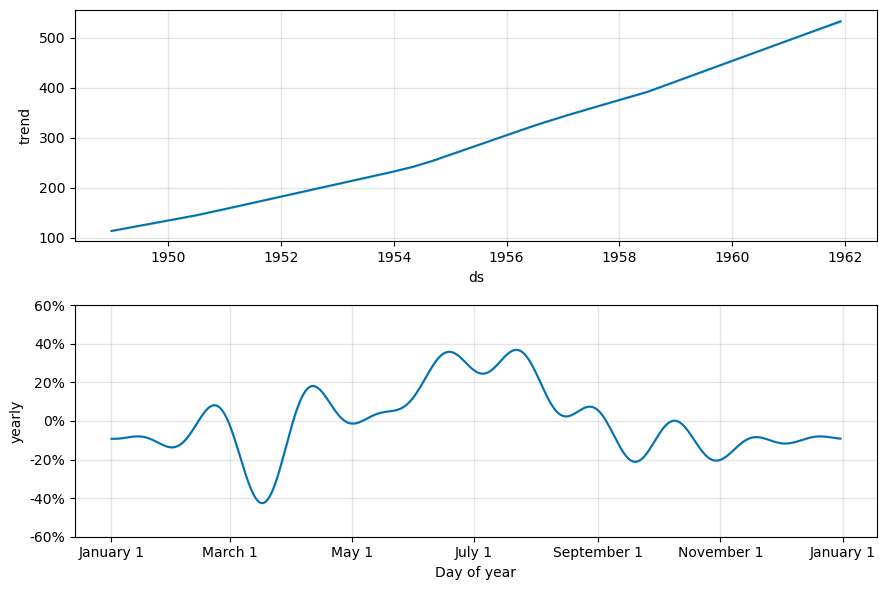

In [50]:
m2.plot_components(forecast);

In [51]:
''' ONE WAY TO AVOID USING MULTIPLICATIVE SEASONALITY IS BY USING LOG OF THE DATA'''

' ONE WAY TO AVOID USING MULTIPLICATIVE SEASONALITY IS BY USING LOG OF THE DATA'

In [52]:
logdf =  df.copy()
logdf['y'] = np.log(logdf['y'])

In [53]:
logdf.head()

,y,ds
Month,,
1949-01-01,4.718499,1949-01-01
1949-02-01,4.770685,1949-02-01
1949-03-01,4.882802,1949-03-01
1949-04-01,4.859812,1949-04-01
1949-05-01,4.795791,1949-05-01


In [55]:
m3 = Prophet() # default seasonality mode being used which is additive

m3.fit(logdf)

future = m3.make_future_dataframe(periods = 12, freq = 'MS')

forecast = m3.predict(future)

20:58:34 - cmdstanpy - INFO - Chain [1] start processing
20:58:34 - cmdstanpy - INFO - Chain [1] done processing


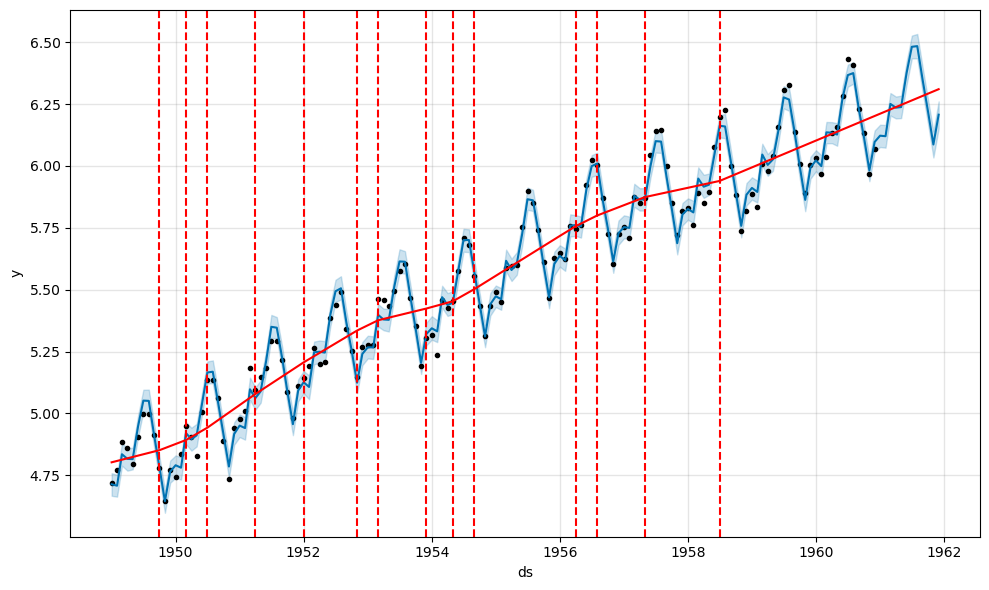

In [56]:
fig = m3.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m3, forecast)

In [58]:
''' bit too sensitive with the changepoints but doing a good job'''

' bit too sensitive with the changepoints but doing a good job'

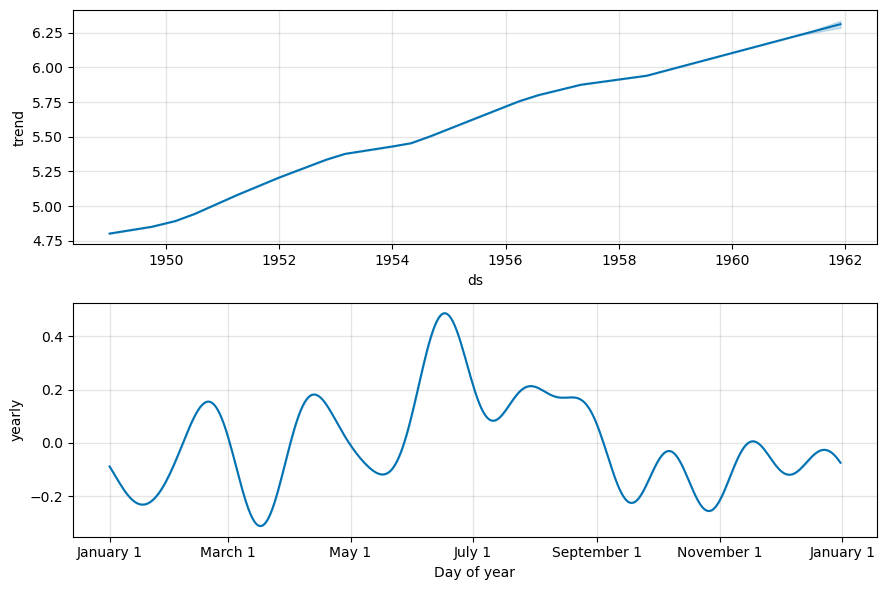

In [59]:
m3.plot_components(forecast);

### Outliers

In [60]:
df.loc['1955-01-01', 'y'] = 600
df.loc['1957-06-01', 'y'] = 1

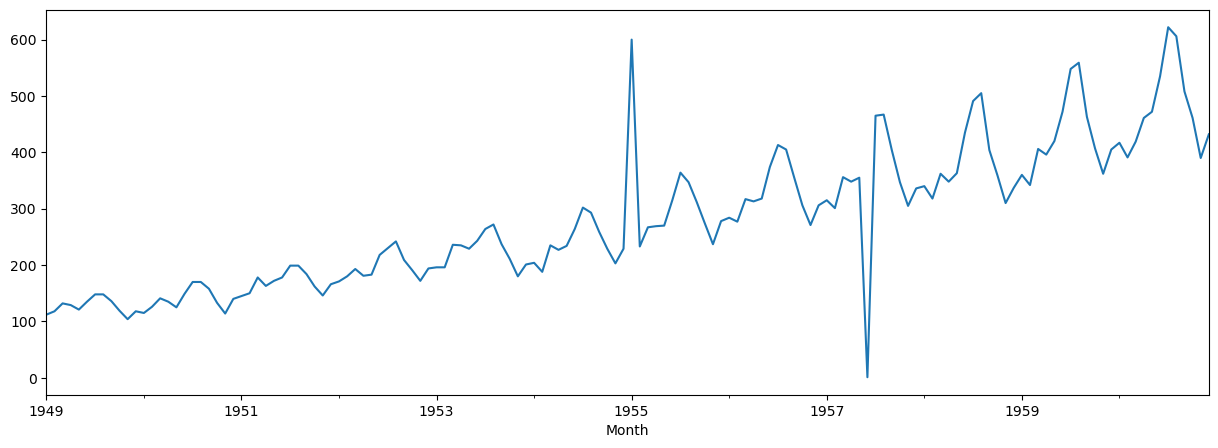

In [61]:
df['y'].plot(figsize =(15,5));

21:11:55 - cmdstanpy - INFO - Chain [1] start processing
21:11:55 - cmdstanpy - INFO - Chain [1] done processing


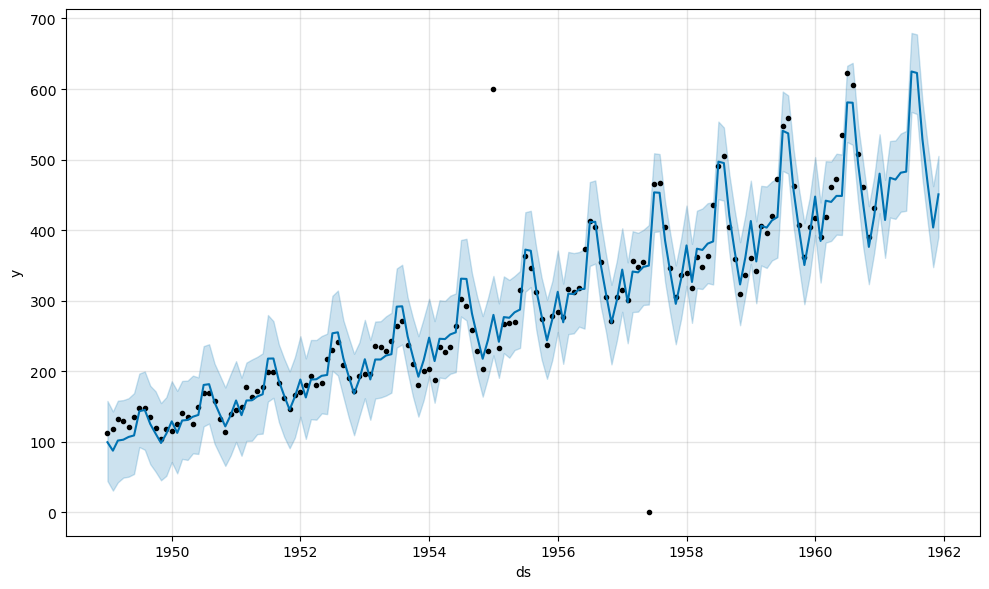

In [63]:
m = Prophet(seasonality_mode = 'multiplicative')
m.fit(df)
future = m.make_future_dataframe(periods = 12, freq = 'MS')
forecast = m.predict(future)
m.plot(forecast);

In [67]:
''' model predicting well but confidence interval has now increased due to outliers '''
'''this makes sense since if the model has seen some very large and very small values, it may expect to see them again in future
making it less confident on its own predictions'''

'this makes sense since if the model has seen some very large and very small values, it may expect to see them again in future\nmaking it less confident on its own predictions'

In [68]:
df2 = df[~df.index.isin(['1955-01-01','1957-06-01'])]

C:\Users\palit\AppData\Local\Temp\ipykernel_6088\2054227522.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df2 = df[~df.index.isin(['1955-01-01','1957-06-01'])]


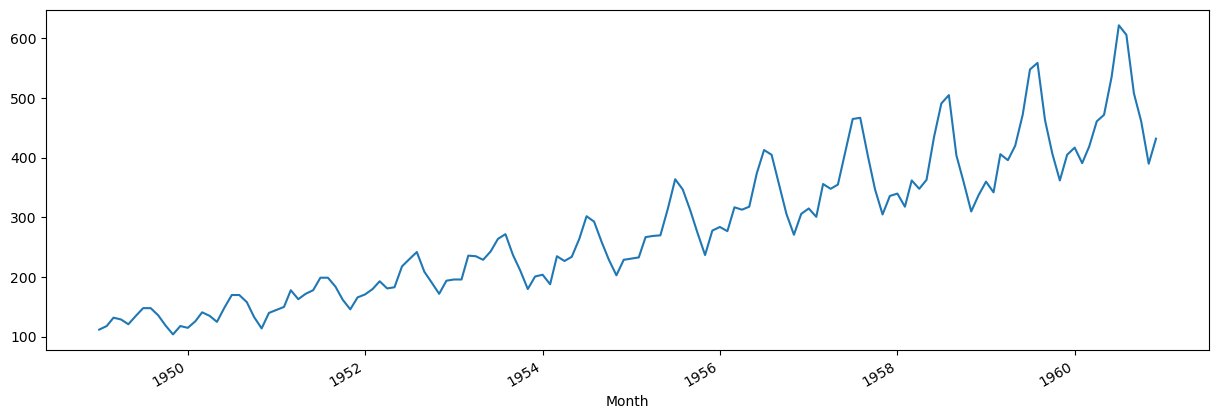

In [69]:
df2['y'].plot(figsize =(15,5));


21:27:46 - cmdstanpy - INFO - Chain [1] start processing
21:27:46 - cmdstanpy - INFO - Chain [1] done processing


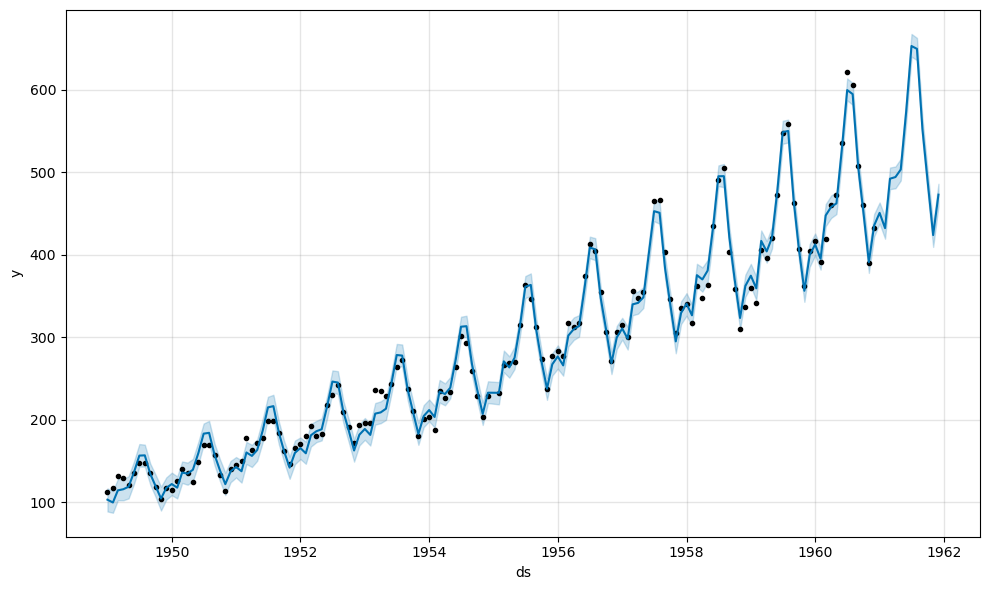

In [70]:
m = Prophet(seasonality_mode = 'multiplicative')
m.fit(df2)
future = m.make_future_dataframe(periods = 12, freq = 'MS')
forecast = m.predict(future)
m.plot(forecast);

In [73]:
''' Prophet can deal with missing data as well - time is the only regressor
so even if we remove the missing data, its not an issue'''
''' the confidence interval is small again'''

' the confidence interval is small again'

In [94]:
# in previous example, we called in a function called .add_country_holidays(country_name ='US'), but this was the lazy way
# the below shows custom way of doing things

In [95]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


In [96]:
# actual data set shown above already includes holidays

In [97]:
#checking unique values of the column StateHoliday
set(store1['StateHoliday'])

{'0', 'a', 'b', 'c'}

In [98]:
# 0 mean

In [99]:
set(store1['SchoolHoliday'])

{0, 1}

In [100]:
df_p.shape

(942, 2)

In [101]:
store1.shape

(942, 8)

In [102]:
df_p['open'] = store1['Open'] # binary either 0 or 1
df_p['promo'] = store1['Promo']  # binary either 0 or 1

df_p[['SH1','SH2','SH3']] = pd.get_dummies(store1['StateHoliday'], drop_first = True) 
# statistical models only work on numbers, dummy encode these values  - drop_first = True to use dummy encoding instead of one hot encoding
#one hot would give us 4 values, dummmy encoding will give us 3 values, 4th value is redundant so we dont have to use it


df_p['SchoolHoliday'] = store1['SchoolHoliday'] #binary 0 or 1

In [103]:
df_p.head()

,y,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
Date,,,,,,,,
2013-01-01,0,2013-01-01,0,0,True,False,False,1
2013-01-02,5530,2013-01-02,1,0,False,False,False,1
2013-01-03,4327,2013-01-03,1,0,False,False,False,1
2013-01-04,4486,2013-01-04,1,0,False,False,False,1
2013-01-05,4997,2013-01-05,1,0,False,False,False,1


In [104]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


In [105]:
''' both the dataframes above have different ordering of their index - but when we do something like df_p['open'] = store1['Open'] , it does kind of 
join based on index of the 2 dataframes'''

" both the dataframes above have different ordering of their index - but when we do something like df_p['open'] = store1['Open'] , it does kind of \njoin based on index of the 2 dataframes"

In [106]:
''' note that the dataframe we are passing in has all the data which has dates on which store was closed'''
''' passing store open/close as a separate regressor'''

m4 = Prophet()
m4.add_regressor('open', mode = 'multiplicative')  # default mode is seasonality model 
# using multiplicative since we think that when store is closed, model will multiply with 0

m4.add_regressor('promo', mode = 'additive')
m4.add_regressor('SH1', mode = 'additive')
m4.add_regressor('SH2', mode = 'additive')
m4.add_regressor('SH3', mode = 'additive')
m4.add_regressor('SchoolHoliday', mode = 'additive')
m4.fit(df_p) 

19:36:10 - cmdstanpy - INFO - Chain [1] start processing
19:36:10 - cmdstanpy - INFO - Chain [1] done processing


In [107]:
future4 = m4.make_future_dataframe(periods = 365)

In [108]:
train_idx = future4['ds'].isin(df_p.index)  
# checking if ds value is in the index for the input dataframe which has train data
# future4 has both insample + 365 days of out of sample dates

test_idx = ~train_idx

In [109]:
future4.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [110]:
''' despite adding the regressors in the m4 model, we dont see the regressors in the future4 dataframe.
Regressors need to be added in the futures dataframe which is required in order to make predictions.
We are specifying the input values to be used for each prediction.

for train set, its easy since it is just the copy of what we had before.

this will be a bit difficult for test set since we dont know when this holiday will be there for the european country.

this is not automatically created since i think test data for regressors is not provided as an input during model training since we only provide 
training data.
'''


' despite adding the regressors in the m4 model, we dont see the regressors in the future4 dataframe.\nRegressors need to be added in the futures dataframe which is required in order to make predictions.\nWe are specifying the input values to be used for each prediction.\n\nfor train set, its easy since it is just the copy of what we had before.\n\nthis will be a bit difficult for test set since we dont know when this holiday will be there for the european country.\n\nthis is not automatically created since i think test data for regressors is not provided as an input during model training since we only provide \ntraining data.\n'

In [111]:
regressors = ['open','promo','SH1','SH2','SH3','SchoolHoliday']
for r in regressors:
    future4.loc[train_idx, r] = df_p[r].to_list()

C:\Users\palit\AppData\Local\Temp\ipykernel_228\2231029197.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, F

In [112]:
future4.head()

,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
0,2013-01-01,0.0,0.0,True,False,False,1.0
1,2013-01-02,1.0,0.0,False,False,False,1.0
2,2013-01-03,1.0,0.0,False,False,False,1.0
3,2013-01-04,1.0,0.0,False,False,False,1.0
4,2013-01-05,1.0,0.0,False,False,False,1.0


In [113]:
future4.tail()

,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
1302,2016-07-26,NaN,NaN,NaN,NaN,NaN,NaN
1303,2016-07-27,NaN,NaN,NaN,NaN,NaN,NaN
1304,2016-07-28,NaN,NaN,NaN,NaN,NaN,NaN
1305,2016-07-29,NaN,NaN,NaN,NaN,NaN,NaN
1306,2016-07-30,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
# the above are blank since they are for test set - adding the below for test set
# pretending we know this for test set (we actually do not since we are not sure which european country this store is located)

future4.loc[test_idx, 'open'] = future4.loc[test_idx, 'ds'].apply(lambda x : 1.0 * (x.weekday() != 6))

# for other regressors, we are simply copy from past 365 days of actual training data # assumption
for r in regressors[1:]:
    future4.loc[test_idx, r] = df_p.iloc[-365:][r].to_list() 

In [115]:
df_p.tail()

,y,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
Date,,,,,,,,
2015-07-27,6102,2015-07-27,1,1,False,False,False,1
2015-07-28,5011,2015-07-28,1,1,False,False,False,1
2015-07-29,4782,2015-07-29,1,1,False,False,False,1
2015-07-30,5020,2015-07-30,1,1,False,False,False,1
2015-07-31,5263,2015-07-31,1,1,False,False,False,1


In [116]:
future4.tail()

,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
1302,2016-07-26,1.0,1.0,False,False,False,1.0
1303,2016-07-27,1.0,1.0,False,False,False,1.0
1304,2016-07-28,1.0,1.0,False,False,False,1.0
1305,2016-07-29,1.0,1.0,False,False,False,1.0
1306,2016-07-30,1.0,1.0,False,False,False,1.0


In [117]:
forecast4 = m4.predict(future4) # if we hadnt added the regressors earlier, it would have thrown error saying regressors missing

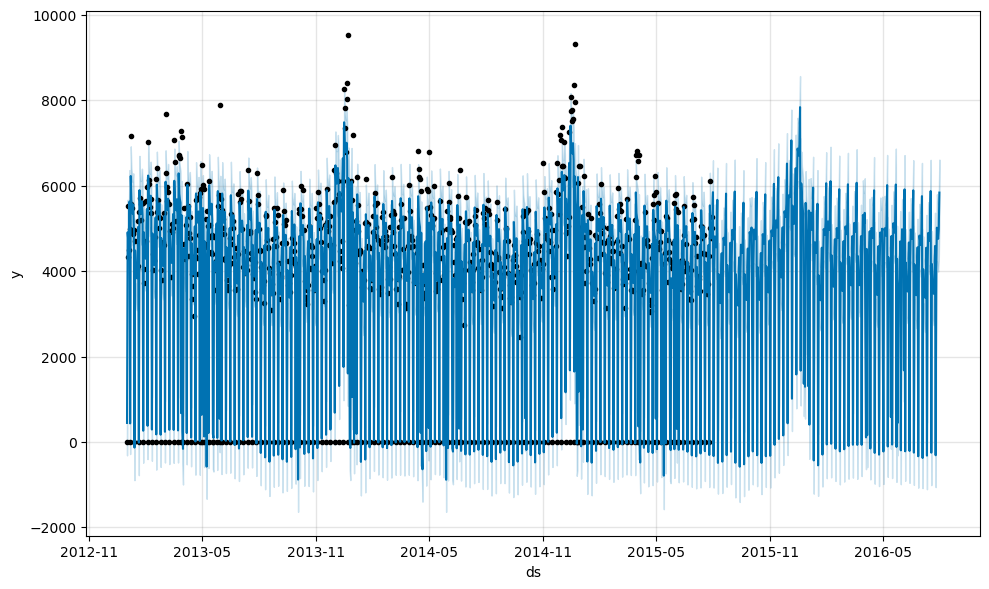

In [118]:
m4.plot(forecast4);

In [119]:
''' 
- not what we expected, model giving us negative values - still doesnt know sales 0 when store is not open
    - we should probably just remove those days from the time series''' 

' \n- not what we expected, model giving us negative values - still doesnt know sales 0 when store is not open\n    - we should probably just remove those days from the time series'

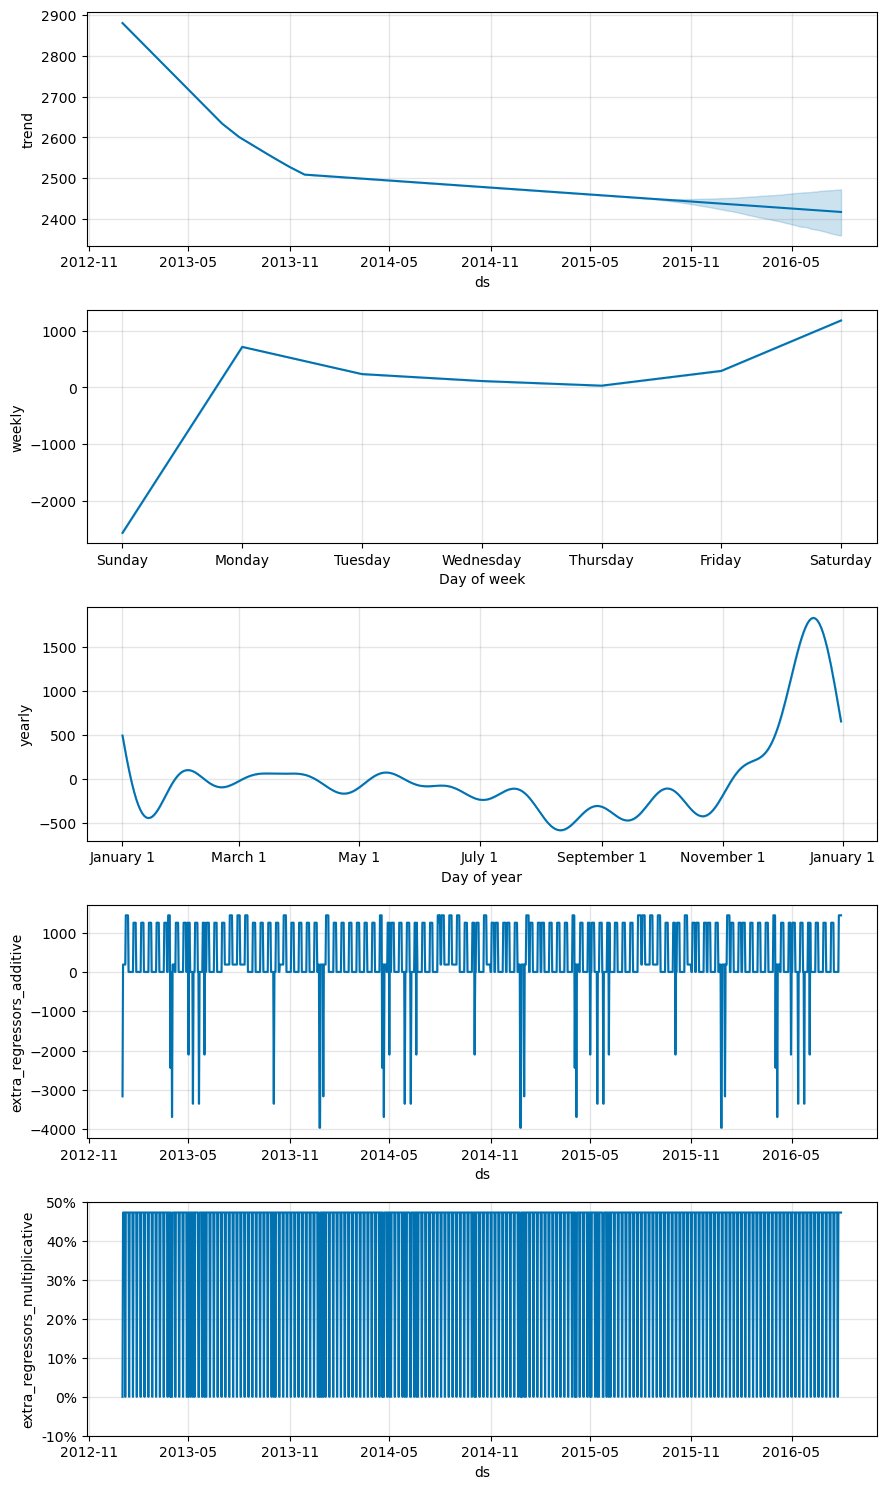

In [120]:
m4.plot_components(forecast4);

In [121]:
''' 
- adding Sun in the data has a negative influence despite adding the 'open' field denoting store open or close
        - better to just remove days when store is closed
- yearly seasonality- we still see the exact graph which came without regressors - still see a peak around winter school holiday
        - meaning adding these new regressors didnt completely account for these events
- components of regressors also plotted based on the mode we specified - additive and multiplicative components
'''

" \n- adding Sun in the data has a negative influence despite adding the 'open' field denoting store open or close\n        - better to just remove days when store is closed\n- yearly seasonality- we still see the exact graph which came without regressors - still see a peak around winter school holiday\n        - meaning adding these new regressors didnt completely account for these events\n- components of regressors also plotted based on the mode we specified - additive and multiplicative components\n"

In [122]:
from prophet.diagnostics import cross_validation

In [123]:
df_cv = cross_validation(
    m,                        # will take in the trained model - SHOULD HAVE USED M2 WHICH EXCLUDES THE DATES WHEN STORES WERE CLOSED
    initial = '730 days',     # this is the initial size of the 1st train set 
    period = '30 days',       # stepping forward the train set size by this much time period -step size
    horizon = '60 days')      # at each iteration of train set, the time period ahead to forecast

  0%|          | 0/6 [00:00<?, ?it/s]

19:36:13 - cmdstanpy - INFO - Chain [1] start processing
19:36:14 - cmdstanpy - INFO - Chain [1] done processing
19:36:14 - cmdstanpy - INFO - Chain [1] start processing
19:36:14 - cmdstanpy - INFO - Chain [1] done processing
19:36:14 - cmdstanpy - INFO - Chain [1] start processing
19:36:14 - cmdstanpy - INFO - Chain [1] done processing
19:36:15 - cmdstanpy - INFO - Chain [1] start processing
19:36:15 - cmdstanpy - INFO - Chain [1] done processing
19:36:15 - cmdstanpy - INFO - Chain [1] start processing
19:36:15 - cmdstanpy - INFO - Chain [1] done processing
19:36:16 - cmdstanpy - INFO - Chain [1] start processing
19:36:16 - cmdstanpy - INFO - Chain [1] done processing


In [124]:
''' m2 model's cross validation - one with data removed for dates when store was closed - is done later on'''

" m2 model's cross validation - one with data removed for dates when store was closed - is done later on"

In [125]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-01-03,4612.183309,3152.030362,6110.746798,5023,2015-01-02
1,2015-01-04,-441.878139,-1881.803109,936.281140,0,2015-01-02
2,2015-01-05,4574.131377,3065.872415,6044.471118,6239,2015-01-02
3,2015-01-06,4189.020494,2739.675534,5599.611202,4574,2015-01-02
4,2015-01-07,3950.876574,2463.069470,5428.341596,4796,2015-01-02
...,...,...,...,...,...,...
355,2015-07-27,4791.395410,3456.807206,6315.533051,6102,2015-06-01
356,2015-07-28,4466.849519,2986.944538,5851.361327,5011,2015-06-01
357,2015-07-29,4252.228830,2748.148245,5586.425944,4782,2015-06-01
358,2015-07-30,3876.622614,2360.738082,5266.906044,5020,2015-06-01


In [126]:
''' 
cut off tells us where we started our forecasts from
ds is the timestamp for each forecasted value - meaning forecast is for date 'ds'
'''


" \ncut off tells us where we started our forecasts from\nds is the timestamp for each forecasted value - meaning forecast is for date 'ds'\n"

In [127]:
''' since 1st date in the training set was 01 jan 2013, 
 - then 1st training set would be 01 jan 2013 + 730 = 01 jan 2015. so the 1st set of predictions would have cut off date from 02/01/2015.
     - predictions for cut off date 02/01/2015 would be from 03/01/2015 to 03/01/2015 + 60 days  = 03/03/15
 - 2nd training set would be from 01/jan/2013 + 730 + 30 = 31 Jan 2015 , so 2nd set of preditioins would have cut off date from 01/02/15
     - predictons for cut off date 01/01/2015 would be from 02/02/2015 to 02/02/2015 +  60 days = 02/04/15
 - .....
 - 1st and 2nd set of predictions for different cut off dates have overlapping dates. eg 15/02/2015 would have 2 predictions one for each cut off date'''
     

' since 1st date in the training set was 01 jan 2013, \n - then 1st training set would be 01 jan 2013 + 730 = 01 jan 2015. so the 1st set of predictions would have cut off date from 02/01/2015.\n     - predictions for cut off date 02/01/2015 would be from 03/01/2015 to 03/01/2015 + 60 days  = 03/03/15\n - 2nd training set would be from 01/jan/2013 + 730 + 30 = 31 Jan 2015 , so 2nd set of preditioins would have cut off date from 01/02/15\n     - predictons for cut off date 01/01/2015 would be from 02/02/2015 to 02/02/2015 +  60 days = 02/04/15\n - .....\n - 1st and 2nd set of predictions for different cut off dates have overlapping dates. eg 15/02/2015 would have 2 predictions one for each cut off date'

In [128]:
from prophet.diagnostics import performance_metrics

In [129]:
pm = performance_metrics(df_cv)
pm

,horizon,mse,rmse,mae,mdape,smape,coverage
0,6 days,2.223636e+06,1491.186110,919.609816,0.138169,0.550357,0.805556
1,7 days,1.587809e+06,1260.082987,758.556450,0.134227,0.491755,0.833333
2,8 days,1.462808e+06,1209.465833,705.495506,0.124071,0.486258,0.888889
3,9 days,1.165782e+06,1079.713909,689.723887,0.145229,0.453825,0.916667
4,10 days,5.043820e+05,710.198599,578.954183,0.156795,0.460461,0.944444
5,11 days,4.956430e+05,704.019148,570.084299,0.148970,0.403627,0.944444
6,12 days,8.562216e+05,925.322413,634.406011,0.148970,0.450544,0.944444
7,13 days,8.255995e+05,908.625081,605.628842,0.135744,0.441898,0.944444
8,14 days,7.805913e+05,883.510801,566.032339,0.123950,0.433057,0.944444
9,15 days,6.533861e+05,808.323022,496.764729,0.103078,0.414432,0.972222


In [130]:
''' mape is not present above since mape formula is average(abs(delta)/y_actual). Since y_actual is 0 in some cases, mape has been skipped'''

' mape is not present above since mape formula is average(abs(delta)/y_actual). Since y_actual is 0 in some cases, mape has been skipped'

In [131]:
''' 
since the last training data is 31st july 2015, and  horizon if 60 days , the last cutoff could not be greater than 01st June 2015
default horizon is 10% of horizon - 10% of 60 days  = 6 days
so, it looks at multiple iterations of different training set / test set combinations 
and then looks at forecasts 6 days ahead of the cut off date for each this combinations
    - average error of all predictions made exactly 6 days after the 'cutoff'
and calculates the average of mapes , mse etc for 6 days ahead of the cut off for each combination.

Similarly, it does it for 7 days ,,,,,going all the way to looking 60 days + cutoff for each of the combination to calculate the metrics '''


" \nsince the last training data is 31st july 2015, and  horizon if 60 days , the last cutoff could not be greater than 01st June 2015\ndefault horizon is 10% of horizon - 10% of 60 days  = 6 days\nso, it looks at multiple iterations of different training set / test set combinations \nand then looks at forecasts 6 days ahead of the cut off date for each this combinations\n    - average error of all predictions made exactly 6 days after the 'cutoff'\nand calculates the average of mapes , mse etc for 6 days ahead of the cut off for each combination.\n\nSimilarly, it does it for 7 days ,,,,,going all the way to looking 60 days + cutoff for each of the combination to calculate the metrics "

In [132]:
''' as we predict further away from the future (meaning the horixon increaes in the above dataframe), the model should be less and less confident
cutoff'''

' as we predict further away from the future (meaning the horixon increaes in the above dataframe), the model should be less and less confident\ncutoff'

In [133]:
from prophet.plot import plot_cross_validation_metric

C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


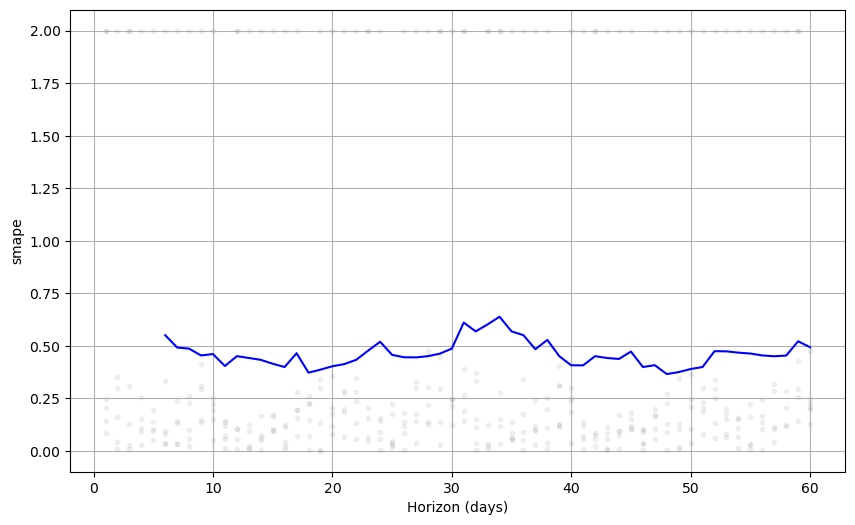

In [134]:
plot_cross_validation_metric(df_cv, metric ='smape');

In [135]:
''' 
blue line rolling window estimate of all the cutoffs for a horizon
raw metrics as a scatter plot of individual cut off
error stays relatively constant
'''

' \nblue line rolling window estimate of all the cutoffs for a horizon\nraw metrics as a scatter plot of individual cut off\nerror stays relatively constant\n'

In [136]:
df_cv2 = cross_validation(
    m2,
    initial = '730 days',
    period = '30 days',
    horizon = '60 days')

  0%|          | 0/6 [00:00<?, ?it/s]

19:37:24 - cmdstanpy - INFO - Chain [1] start processing
19:37:24 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:25 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:25 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing
19:37:26 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing
19:37:26 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing


In [137]:
pm2 = performance_metrics(df_cv2)

In [143]:
pm2.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days,529216.347810,727.472575,565.929613,0.124764,0.098103,0.119359,0.862069
1,8 days,503482.186781,709.564787,579.996711,0.139841,0.108191,0.127566,0.862069
2,9 days,812290.818127,901.271778,740.285953,0.194879,0.148424,0.169598,0.758621
3,10 days,948790.173116,974.058609,832.200844,0.223361,0.200755,0.192755,0.689655
4,11 days,952684.325814,976.055493,850.329483,0.227789,0.200755,0.197441,0.703448


In [144]:
''' since we had removed the dates when store was closed, now mape becomes defined for all datapoints since y_act is never 0'''

' since we had removed the dates when store was closed, now mape becomes defined for all datapoints since y_act is never 0'

C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


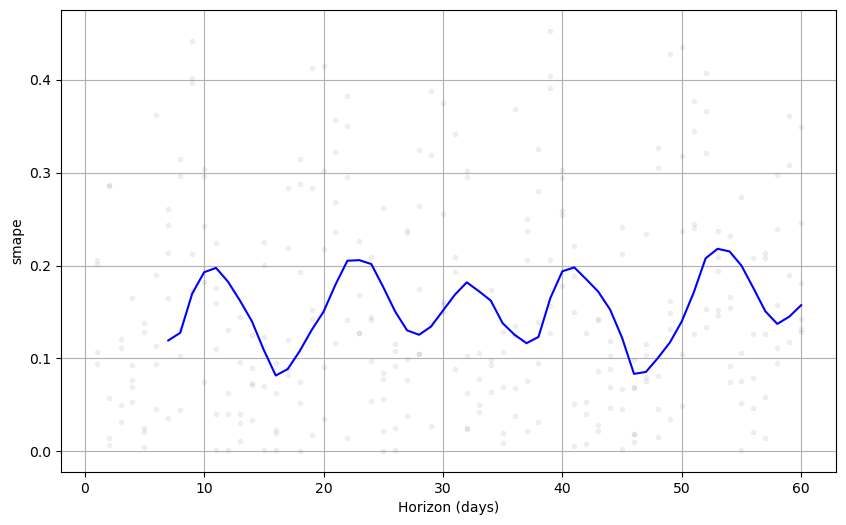

In [139]:
plot_cross_validation_metric(df_cv2, metric = 'smape');

In [140]:
''' cyclical pattern but overall smape moving average showing less smape compared to the previous model
although individual raw data scatter plot smape does look increased '''


' cyclical pattern but overall smape moving average showing less smape compared to the previous model\nalthough individual raw data scatter plot smape does look increased '

In [146]:
df_cv3 = cross_validation(
    m3, # this is where we added US holidays 
    initial = '730 days',
    period = '30 days',
    horizon = '60 days')

  0%|          | 0/6 [00:00<?, ?it/s]

19:44:24 - cmdstanpy - INFO - Chain [1] start processing
19:44:24 - cmdstanpy - INFO - Chain [1] done processing
19:44:24 - cmdstanpy - INFO - Chain [1] start processing
19:44:24 - cmdstanpy - INFO - Chain [1] done processing
19:44:25 - cmdstanpy - INFO - Chain [1] start processing
19:44:25 - cmdstanpy - INFO - Chain [1] done processing
19:44:25 - cmdstanpy - INFO - Chain [1] start processing
19:44:25 - cmdstanpy - INFO - Chain [1] done processing
19:44:26 - cmdstanpy - INFO - Chain [1] start processing
19:44:26 - cmdstanpy - INFO - Chain [1] done processing
19:44:26 - cmdstanpy - INFO - Chain [1] start processing
19:44:26 - cmdstanpy - INFO - Chain [1] done processing


In [147]:
pm3 = performance_metrics(df_cv3)
pm3.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days,528266.807794,726.819653,563.802626,0.124251,0.098476,0.118839,0.862069
1,8 days,504209.060183,710.076799,578.112304,0.139371,0.112942,0.127113,0.862069
2,9 days,814044.403389,902.244093,738.635119,0.194492,0.150499,0.169189,0.758621
3,10 days,951362.314033,975.378036,832.049957,0.223229,0.197754,0.192647,0.689655
4,11 days,954549.058384,977.010265,849.699175,0.227534,0.199710,0.197283,0.703448


C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


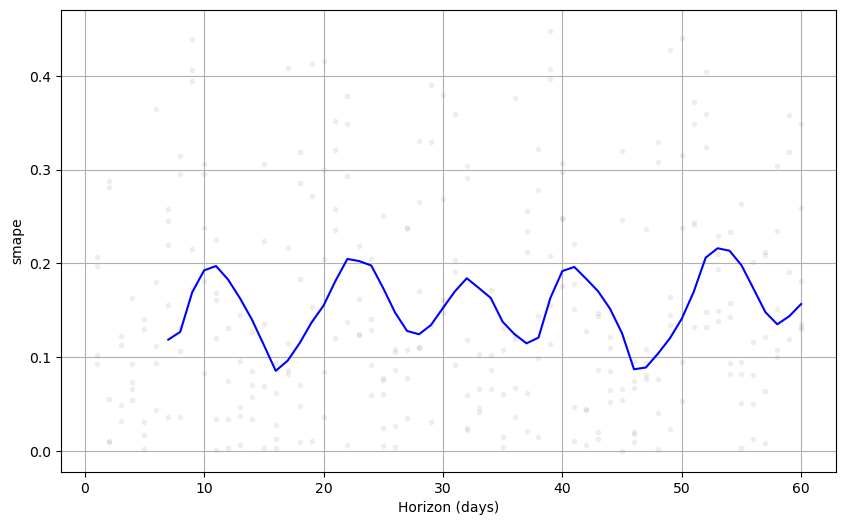

In [150]:
plot_cross_validation_metric(df_cv3, metric = 'smape');

In [151]:
df_cv4 = cross_validation(
    m4, # this is where we added external regressors
    initial = '730 days',
    period = '30 days',
    horizon = '60 days')

pm4 = performance_metrics(df_cv4)

  0%|          | 0/6 [00:00<?, ?it/s]

19:46:20 - cmdstanpy - INFO - Chain [1] start processing
19:46:20 - cmdstanpy - INFO - Chain [1] done processing
19:46:21 - cmdstanpy - INFO - Chain [1] start processing
19:46:21 - cmdstanpy - INFO - Chain [1] done processing
19:46:21 - cmdstanpy - INFO - Chain [1] start processing
19:46:21 - cmdstanpy - INFO - Chain [1] done processing
19:46:22 - cmdstanpy - INFO - Chain [1] start processing
19:46:22 - cmdstanpy - INFO - Chain [1] done processing
19:46:22 - cmdstanpy - INFO - Chain [1] start processing
19:46:22 - cmdstanpy - INFO - Chain [1] done processing
19:46:23 - cmdstanpy - INFO - Chain [1] start processing
19:46:23 - cmdstanpy - INFO - Chain [1] done processing


C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


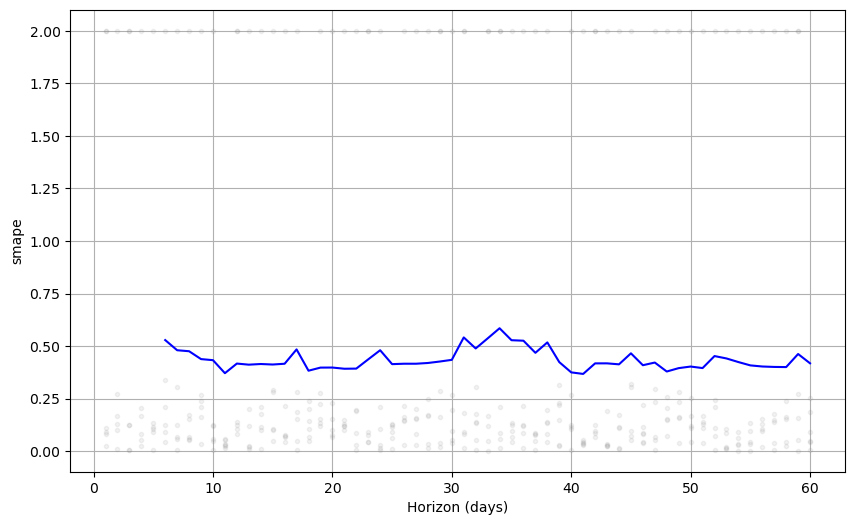

In [152]:
plot_cross_validation_metric(df_cv4, metric = 'smape');

In [154]:
''' similar pattern as the 1st model - 1st model and the 4th model both had negative yhats - both 1st and 4th included 0 sale days  '''

' similar pattern as the 1st model - 1st model and the 4th model both had negative yhats - both 1st and 4th included 0 sale days  '

In [155]:
pm['smape'].mean(),pm2['smape'].mean(),pm3['smape'].mean(),pm4['smape'].mean() 

(0.461775405515676,
 0.15371307521687194,
 0.15402386271741614,
 0.4357805114466114)

In [158]:
'''1st model worst smape, 4th model where we added external regressors but kept the store close dates as well'''
''' best mape was model where we just removed the store close dates . 3rd model where we added US holiday and kept the store close dates removed 
didnt help'''

' best mape was model where we just removed the store close dates . 3rd model where we added US holiday and kept the store close dates removed \ndidnt help'

In [156]:
'''the best model came when we just removed the dates when store was closed, we could have tried 4th model where we added regressors
but we kept the dates when store was closed - maybe try other model with external regressors and removing dates when store was closed'''

'the best model came when we just removed the dates when store was closed, we could have tried 4th model where we added regressors\nbut we kept the dates when store was closed - maybe try other model with external regressors and removing dates when store was closed'

In [160]:
from prophet.plot import add_changepoints_to_plot

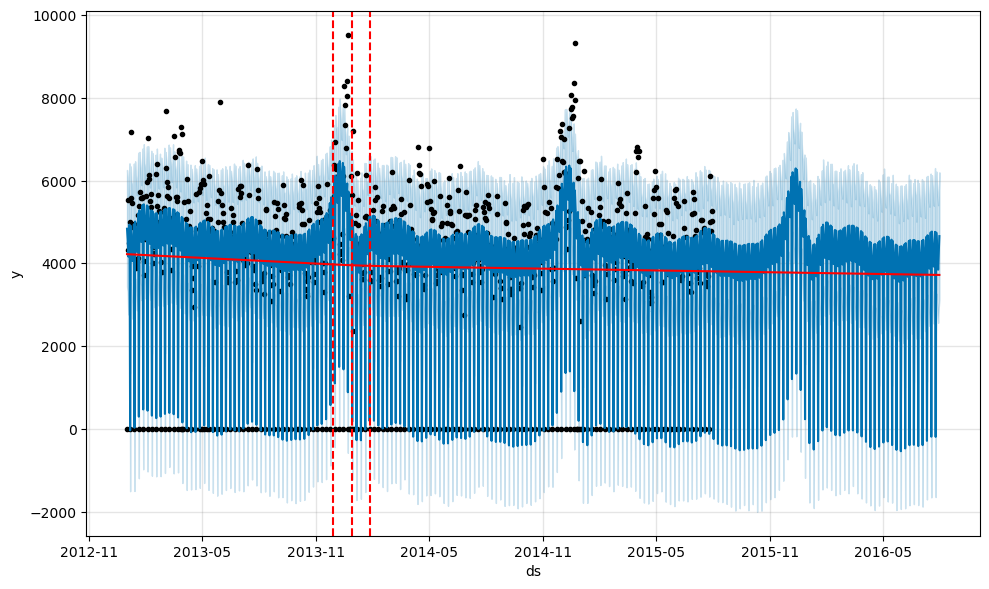

In [161]:
fig =  m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [162]:
''' 2 changepoints - trend goes from more steep to less steep'''

' 2 changepoints - trend goes from more steep to less steep'

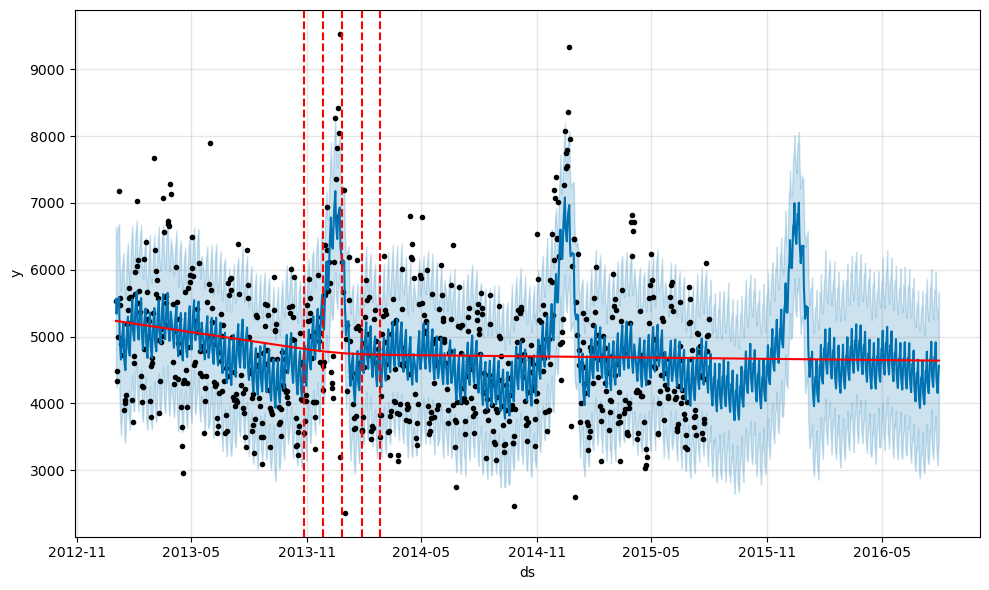

In [163]:
fig = m2.plot(forecast2)
a =  add_changepoints_to_plot(fig.gca(), m2, forecast2)

In [166]:
''' why are changepoints equally spaced?
-n_changepoints = 25 , model chooses the changepoints from amonf those changepoints '''

' why are changepoints equally spaced?\n-n_changepoints = 25 , model chooses the changepoints from amonf those changepoints '

In [167]:
'''many more changepoints here - these are governed by the parameters we pass inside the model object'''

# - changepoints parameter
# - n_changepoints - !!! BY DEFAULT THIS IS 25, MODEL IS CHOOSING THE CHANGEPOINTS FROM AMONG THOSE 25
# - changepoint_range
# - changepoint_prior_scale


'''
 m = Prophet(
                growth  = 'linear',                      # or 'logistic'
                changepoints = None,                     # or list of time stamps 
                n_changepoints = 25,                     # if no explicit timestamps provided above 
                changepoint_range = 0.8,                 # percentage of dataset where we want the potential changepoint to exist # if set to 80%, means no changepoint will
                                                         # exist in the final 20% of your dataset.
                                                         # reason for this parameter is it might overfit due to lack of data near the end
                yearly_seasonality = 'auto',             # or True/False
                weekly_seasonality ='auto',              # or True/False     
                daily_seasonality ='auto',               # or True/False     
                holidays= None,                          # or dataframe # pass in ur holidays, in a specially formatted dataframe with those dates # allows to specify surrounding days and other options
                seasonality_mode = 'additive',           # or 'multiplicative'
                seasonality_prior_scale = 10.0,          # since prophet is a bayesian model, tune the below based on the fitted values - try these values untill u get reasonable results 
                holidays_prior_scale = 10.0, 
                changepoint_prior_scale = 0.05,          # increase or decrease the sensitivity of the changepoints
                MCMC = ,                                 # not discussed here
                uncertainity intervals =,                # not discussed here 
                )
'''
           

"\n m = Prophet(\n                growth  = 'linear',                      # or 'logistic'\n                changepoints = None,                     # or list of time stamps \n                n_changepoints = 25,                     # if no explicit timestamps provided above \n                changepoint_range = 0.8,                 # percentage of dataset where we want the potential changepoint to exist # if set to 80%, means no changepoint will\n                                                         # exist in the final 20% of your dataset.\n                                                         # reason for this parameter is it might overfit due to lack of data near the end\n                yearly_seasonality = 'auto',             # or True/False\n                weekly_seasonality ='auto',              # or True/False     \n                daily_seasonality ='auto',               # or True/False     \n                holidays= None,                          # or dataframe # pas

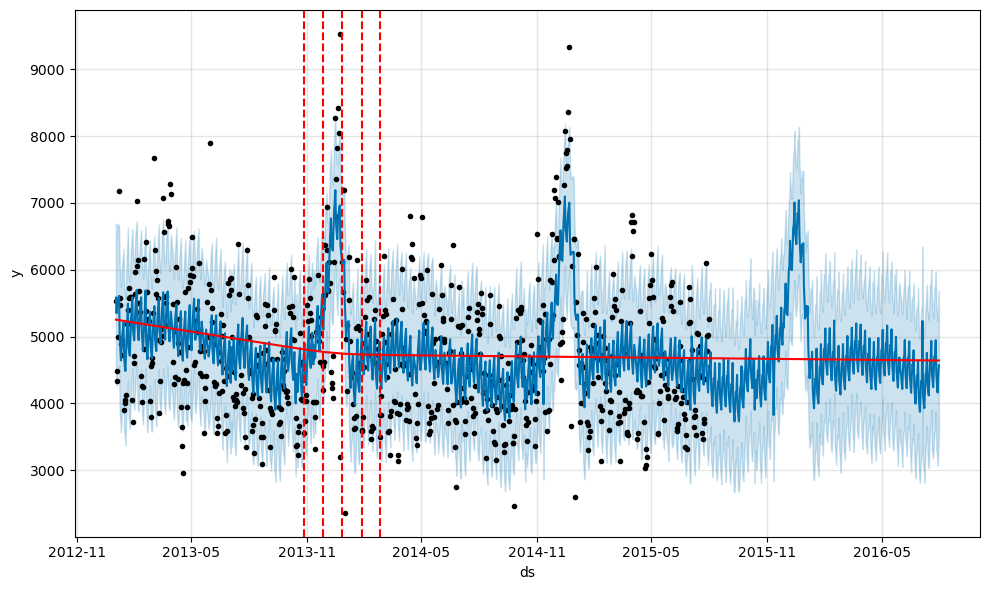

In [169]:
fig = m3.plot(forecast3)
a =  add_changepoints_to_plot(fig.gca(), m3, forecast3)

In [170]:
''' pretty much the same result'''

' pretty much the same result'

In [171]:
''' TUNING THE PRIOR FOR CHANGEPOINT DETECTION'''

' TUNING THE PRIOR FOR CHANGEPOINT DETECTION'

In [174]:
# by changing the prior changepoint_prior_scale, by default it is 0.05.
# increasing this will increase the flexibility making it overfit 

20:09:24 - cmdstanpy - INFO - Chain [1] start processing
20:09:24 - cmdstanpy - INFO - Chain [1] done processing


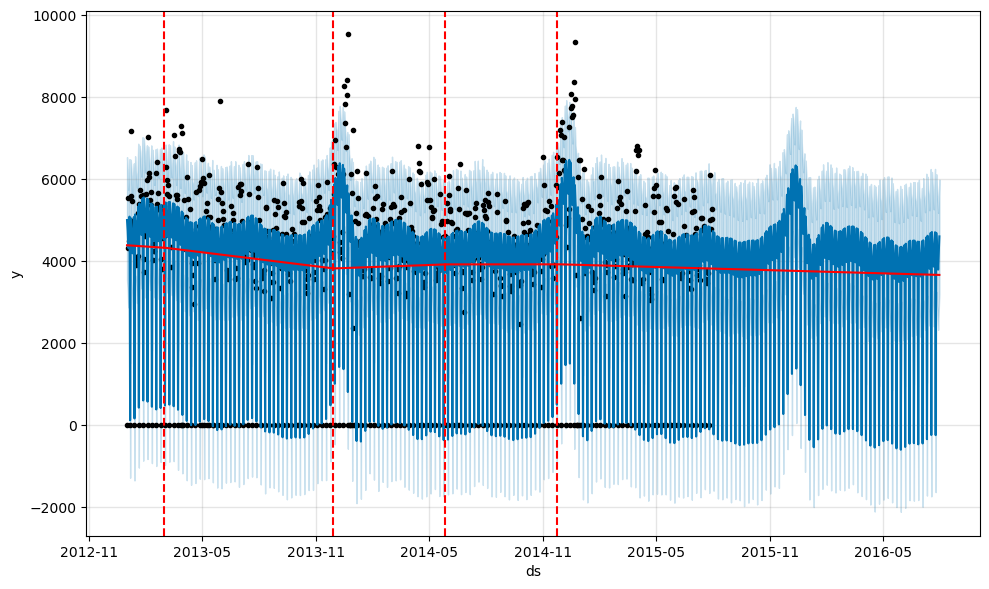

In [179]:
m_a = Prophet(changepoint_prior_scale=0.5) # by default it is 0.05
forecast_a = m_a.fit(df_p).predict(future)
fig = m_a.plot(forecast_a)
a = add_changepoints_to_plot(fig.gca(), m_a, forecast_a)

In [180]:
''' more changepoints appears now since we increased the prior leading to more flexibility'''

' more changepoints appears now since we increased the prior leading to more flexibility'

20:11:29 - cmdstanpy - INFO - Chain [1] start processing
20:11:29 - cmdstanpy - INFO - Chain [1] done processing


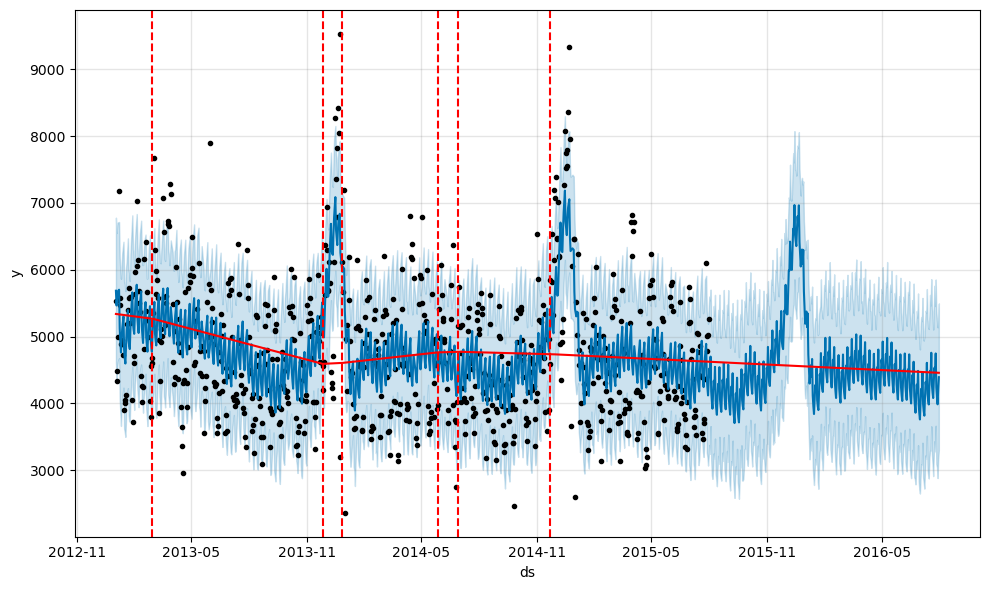

In [181]:
m2_a = Prophet(changepoint_prior_scale=0.5) # by default it is 0.05
forecast2_a = m2_a.fit(df_p2).predict(future2)
fig = m2_a.plot(forecast2_a)
a = add_changepoints_to_plot(fig.gca(), m2_a, forecast2_a)

In [183]:
''' more changepoints'''

' more changepoints'

20:11:52 - cmdstanpy - INFO - Chain [1] start processing
20:11:52 - cmdstanpy - INFO - Chain [1] done processing


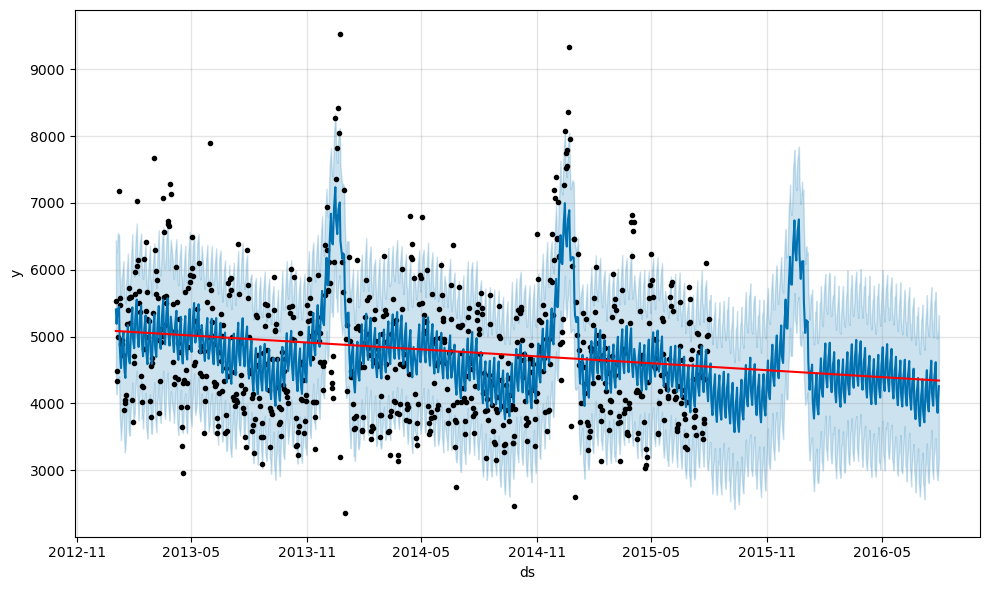

In [182]:
m2_a = Prophet(changepoint_prior_scale=0.005) # by default it is 0.05
forecast2_a = m2_a.fit(df_p2).predict(future2)
fig = m2_a.plot(forecast2_a)
a = add_changepoints_to_plot(fig.gca(), m2_a, forecast2_a)

In [184]:
''' less changepoints since we decreased the prior'''

' less changepoints since we decreased the prior'